# Enceladus interior tides: TidalPy vs Tobie+ (2005) and Roberts & Nimmo (2008)

The Earth Love-number benchmark checked the radial solver's *surface* output. This one checks its
*interior* solution: the radial functions `y1`..`y4` that describe how the tide deforms and stresses the
body with depth. We reproduce two published studies of a tidally flexed, Enceladus-like moon:

- **Tobie et al. (2005)** and **Roberts & Nimmo (2008)** each give the radial profiles of the tidal
  `y`-functions for a few interior structures.

We build the same interior structures, solve them with `RadialSolver_x`, and overlay TidalPy's `y`
profiles on the digitized values from those papers (bundled with TidalPy's plotting utilities). Close
tracking of the curves is the benchmark.

The three structures, all with the same bulk density (3500 kg/m^3) and a Maxwell mantle: a homogeneous
body, and two with a denser liquid core (5150 and 8000 kg/m^3), whose core radius follows from mass
balance.


In [1]:
%matplotlib inline
import logging
import numpy as np

logging.disable(logging.WARNING)   # the solver notes high step counts for these stiff solves

from TidalPy.RadialSolver_x import build_rs_input_homogeneous_layers, radial_solver
from TidalPy.rheology_x import Maxwell, Elastic
from TidalPy.Utilities_x.graphics_x import plot_ys

R_PLANET = 1600.0e3
BULK_DENSITY = 3500.0
MANTLE_DENSITY = 3300.0
MANTLE_SHEAR = 6.6825e10
MANTLE_BULK = 1.2210e11
MANTLE_VISCOSITY = 1.0e20
CORE_BULK = 2.88e11
CORE_VISCOSITY = 1.0e4

def core_radius(core_density):
    return ((BULK_DENSITY - MANTLE_DENSITY) / (core_density - MANTLE_DENSITY))**(1.0 / 3.0) * R_PLANET

def solve_model(forcing, core_density=None):
    "Return (y-functions (6, N), radius grid) for a homogeneous body or one with a liquid core."
    if core_density is None:
        rs = build_rs_input_homogeneous_layers(
            R_PLANET, forcing, (BULK_DENSITY,), (MANTLE_BULK,), (MANTLE_SHEAR,), (1e30,), (MANTLE_VISCOSITY,),
            ("solid",), (False,), (False,), Maxwell(), Elastic(),
            radius_fraction_tuple=(1.0,), slice_per_layer=80)
    else:
        frac = core_radius(core_density) / R_PLANET
        rs = build_rs_input_homogeneous_layers(
            R_PLANET, forcing, (core_density, MANTLE_DENSITY), (CORE_BULK, MANTLE_BULK),
            (1e-9, MANTLE_SHEAR), (1e30, 1e30), (CORE_VISCOSITY, MANTLE_VISCOSITY),
            ("liquid", "solid"), (True, False), (False, False),
            Maxwell(), Elastic(),   # one rheology model applies to every layer
            radius_fraction_tuple=(frac, 1.0), slice_per_layer=80)
    sol = radial_solver(*rs, degree_l=2, solve_for=("tidal",), nondimensionalize=True)
    return np.asarray(sol.result), np.asarray(rs[0]), complex(np.atleast_1d(sol.k)[0])

print(f"core radii: Core 1 = {core_radius(5150.0)/1e3:.0f} km, Core 2 = {core_radius(8000.0)/1e3:.0f} km")


core radii: Core 1 = 762 km, Core 2 = 559 km


C:\venvs\tpy13\Lib\site-packages\TidalPy\__init__.py:55: TidalPyDeprecationWarning: TidalPy's backend is changing: the classic modules (structures, tides, RadialSolver, rheology, ...) are deprecated and will be replaced by the new C++ backend (structures_x, Tides_x, RadialSolver_x, rheology_x, ...) in a future major release. New development happens in the `_x` modules. See the porting guide at https://tidalpy.readthedocs.io/en/latest/future_structure.html. Silence this message with warnings.filterwarnings('ignore', category=TidalPy.exceptions.TidalPyDeprecationWarning).
  _warnings.warn(


> Note: the input builder helpers (`build_rs_input_*`) accept the classic `TidalPy.rheology` model objects, which is why this notebook imports them instead of the newer `TidalPy.rheology_x` classes taught in the demos. The builders and their rheology interface will migrate together when the classic backend is retired.


## Comparison with Tobie et al. (2005)

At Tobie's forcing period (0.9 day), the three structures' radial-displacement (`y1`), radial-stress (`y2`), tangential-displacement (`y3`), and tangential-stress (`y4`) profiles are plotted against the digitized Tobie+2005 points. TidalPy's curves pass through the reference markers.

k2: homogeneous 0.0205, core 1 0.0340, core 2 0.0242


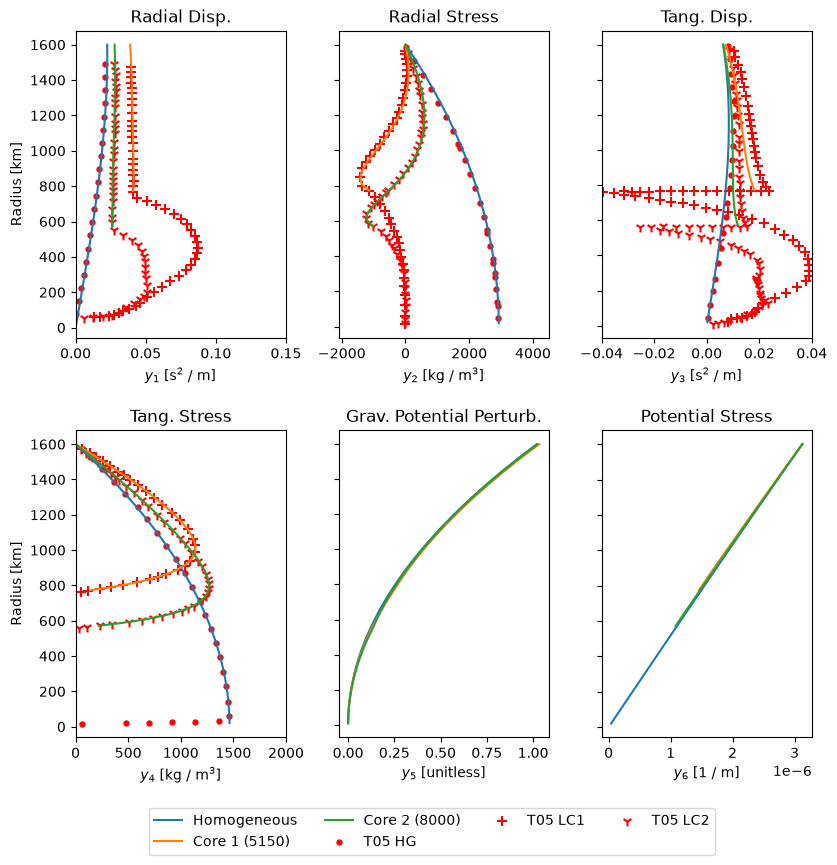

(<Figure size 950x950 with 6 Axes>,
 array([[<Axes: title={'center': 'Radial Disp.'}, xlabel='$y_{1}$ [s$^{2}$ / m]', ylabel='Radius [km]'>,
         <Axes: title={'center': 'Radial Stress'}, xlabel='$y_{2}$ [kg / m$^{3}$]'>,
         <Axes: title={'center': 'Tang. Disp.'}, xlabel='$y_{3}$ [s$^{2}$ / m]'>],
        [<Axes: title={'center': 'Tang. Stress'}, xlabel='$y_{4}$ [kg / m$^{3}$]', ylabel='Radius [km]'>,
         <Axes: title={'center': 'Grav. Potential Perturb.'}, xlabel='$y_{5}$ [unitless]'>,
         <Axes: title={'center': 'Potential Stress'}, xlabel='$y_{6}$ [1 / m]'>]],
       dtype=object))

In [2]:
forcing_tobie = 2.0 * np.pi / (86400.0 * 0.9)
homog = solve_model(forcing_tobie)
core1 = solve_model(forcing_tobie, core_density=5150.0)
core2 = solve_model(forcing_tobie, core_density=8000.0)
print(f"k2: homogeneous {homog[2].real:.4f}, core 1 {core1[2].real:.4f}, core 2 {core2[2].real:.4f}")

plot_ys([homog[0], core1[0], core2[0]], [homog[1], core1[1], core2[1]],
        planet_radius=R_PLANET, benchmarks="tobie2005", use_tobie_limits=True, show_plot=True,
        labels=["Homogeneous", "Core 1 (5150)", "Core 2 (8000)"])


## Comparison with Roberts & Nimmo (2008)

Repeating the same structures at the Roberts & Nimmo forcing frequency, overlaid on their digitized profiles.

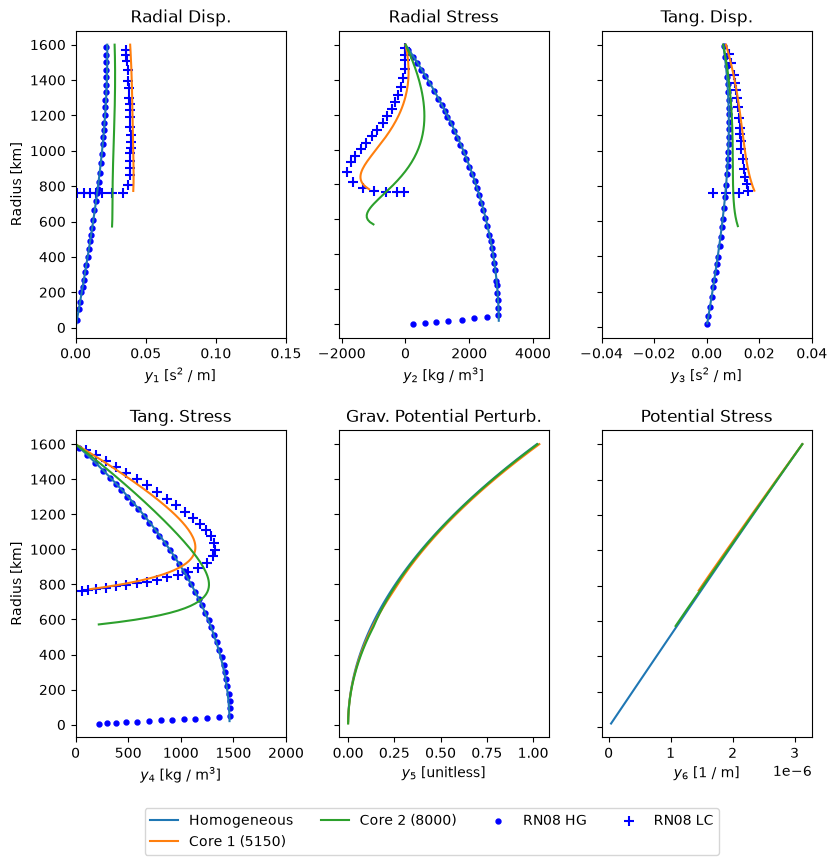

(<Figure size 950x950 with 6 Axes>,
 array([[<Axes: title={'center': 'Radial Disp.'}, xlabel='$y_{1}$ [s$^{2}$ / m]', ylabel='Radius [km]'>,
         <Axes: title={'center': 'Radial Stress'}, xlabel='$y_{2}$ [kg / m$^{3}$]'>,
         <Axes: title={'center': 'Tang. Disp.'}, xlabel='$y_{3}$ [s$^{2}$ / m]'>],
        [<Axes: title={'center': 'Tang. Stress'}, xlabel='$y_{4}$ [kg / m$^{3}$]', ylabel='Radius [km]'>,
         <Axes: title={'center': 'Grav. Potential Perturb.'}, xlabel='$y_{5}$ [unitless]'>,
         <Axes: title={'center': 'Potential Stress'}, xlabel='$y_{6}$ [1 / m]'>]],
       dtype=object))

In [3]:
forcing_roberts = 5.308e-5
homog_r = solve_model(forcing_roberts)
core1_r = solve_model(forcing_roberts, core_density=5150.0)
core2_r = solve_model(forcing_roberts, core_density=8000.0)

plot_ys([homog_r[0], core1_r[0], core2_r[0]], [homog_r[1], core1_r[1], core2_r[1]],
        planet_radius=R_PLANET, benchmarks="roberts_nimmo2008", use_tobie_limits=True, show_plot=True,
        labels=["Homogeneous", "Core 1 (5150)", "Core 2 (8000)"])


## Recap

- TidalPy's `RadialSolver_x` reproduces the interior tidal `y`-function profiles (radial and tangential
  displacement and stress) of an Enceladus-like moon from Tobie et al. (2005) and Roberts & Nimmo (2008),
  across homogeneous and liquid-core structures.
- Together with the Earth Love-number benchmark, this checks the solver both at the surface (the Love
  numbers) and throughout the interior (the `y`-functions).
